# 🕵️ Privacy-First Analytics & Feedback Loop

This notebook implements the **iOS Privacy-First Log Audit** strategy.
It focuses on anonymous IDFV-based analysis, privacy-safe metadata grouping, and actionable feedback loops.

In [13]:
import firebase_admin
from firebase_admin import credentials, firestore
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime, timedelta

# Initialize Firebase (Singleton check)
if not firebase_admin._apps:
    cred = credentials.Certificate("serviceAccountKey.json")
    firebase_admin.initialize_app(cred)

db = firestore.client()
print("🔥 Firebase Initialized")

🔥 Firebase Initialized


## 1. Privacy-Safe Data Loading (The iOS Reality)
**Objective**: Load data but immediately apply privacy techniques (Grouping, Bucketing).

- **Device Grouping**: `iPhone14,2` -> `iPhone 13 Series`
- **Time Bucketing**: Latency in buckets (not exact ms)
- **IDFV Only**: No PII.

In [14]:
def map_device_group(model_raw):
    """Maps raw model identifiers to privacy-safe groups."""
    if not isinstance(model_raw, str): return "Unknown"
    if "iPhone14" in model_raw: return "iPhone 13 Series"
    if "iPhone15" in model_raw: return "iPhone 14 Series"
    if "iPhone16" in model_raw: return "iPhone 15 Series"
    if "iPad" in model_raw: return "iPad"
    return "Other iOS Device"

def load_privacy_safe_logs():
    logs_ref = db.collection('analytic_logs')
    docs = logs_ref.stream()
    
    data = []
    for doc in docs:
        d = doc.to_dict()
        # Basic Cleaning
        if 'startTime' in d and d['startTime']:
             d['startTime'] = d['startTime'].replace(tzinfo=None)
        if 'endTime' in d and d['endTime']:
             d['endTime'] = d['endTime'].replace(tzinfo=None)
        
        # Extract Metrics & Flatten
        metrics = d.get('metrics', {})
        
        # Calculate Duration (Fallback to timestamps if metric missing)
        duration = metrics.get('total_duration', 0)
        if duration == 0 and d.get('endTime') and d.get('startTime'):
            duration = (d['endTime'] - d['startTime']).total_seconds()
            
        d['total_duration'] = duration
        d['ui_freeze_count'] = metrics.get('ui_freeze_detected', 0)
        
        # PRIVACY TRANSFORMATION: Device Grouping
        d['device_group'] = map_device_group(d.get('device_model', ''))
        
        data.append(d)
    
    return pd.DataFrame(data)

df = load_privacy_safe_logs()
print(f"📦 Loaded {len(df)} privacy-safe logs")
df.head(3)

📦 Loaded 6 privacy-safe logs


,endTime,id,device_region,metrics,device_model,network_type,sessionType,startTime,status,subject_id,category,total_duration,ui_freeze_count,device_group
0,2026-01-16 07:54:38.904204,2D2E6DA5-F297-4870-92CC-0FB297A82E0F,KR,"{'total_duration': 6.491370916366577, 'total_c...",arm64,wifi,write_view_daily,2026-01-16 07:54:32.412834,completed,8EE2524A-5828-4430-8FBF-3A20CF6D5E56,write_view,6.491371,0,Other iOS Device
1,2026-01-16 08:25:48.779613,4FDC4FC6-3AE4-4F4A-A6DC-51651AFAADB1,KR,"{'total_duration': 19.050832986831665, 'card_s...",arm64,wifi,write_view_daily,2026-01-16 08:25:29.728780,completed,8EE2524A-5828-4430-8FBF-3A20CF6D5E56,write_view,19.050833,0,Other iOS Device
2,2026-01-16 07:49:55.745655,93A80A77-C208-4674-B99F-F688308C9E45,KR,{'step_durations': {'insightPreview': 0.951496...,arm64,wifi,onboarding,2026-01-16 07:49:42.789752,completed,2136E129-0F6F-435E-B5D6-7B7E56E4ADC3,onboarding,12.955903,0,Other iOS Device


## 2. 👑 Decision Maker Dashboard: Retention & Compliance
**Focus**: Global Cohort Retention & Privacy Health Check.

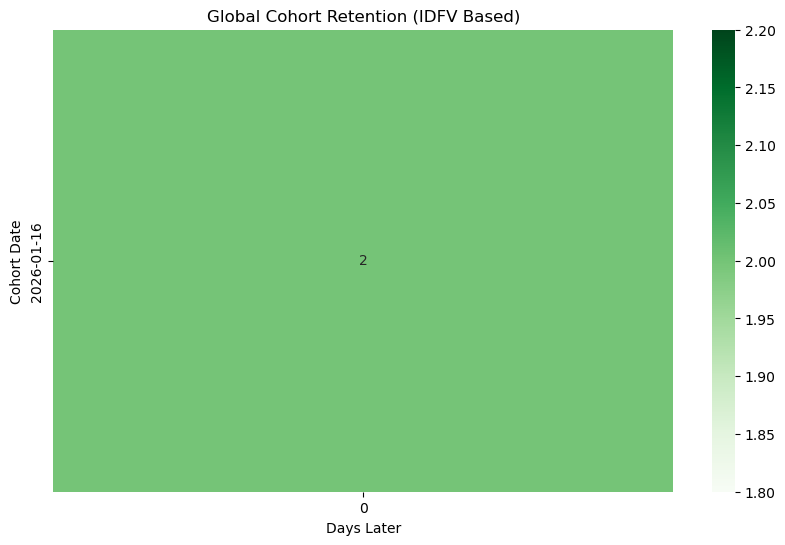

In [15]:
# 1. Global Retention (Day N)
if not df.empty:
    df['date'] = pd.to_datetime(df['startTime']).dt.date
    cohorts = df.groupby('subject_id')['date'].min().reset_index()
    cohorts.columns = ['subject_id', 'first_seen']
    
    df_retention = df.merge(cohorts, on='subject_id')
    df_retention['days_since_first'] = (pd.to_datetime(df_retention['date']) - pd.to_datetime(df_retention['first_seen'])).dt.days
    
    retention_counts = df_retention.groupby(['first_seen', 'days_since_first'])['subject_id'].nunique().unstack()
    
    plt.figure(figsize=(10, 6))
    sns.heatmap(retention_counts, annot=True, fmt='g', cmap='Greens')
    plt.title('Global Cohort Retention (IDFV Based)')
    plt.ylabel('Cohort Date')
    plt.xlabel('Days Later')
    plt.show()

## 3. 💻 Developer Dashboard: Stability & Friction
**Focus**: Crash-free users, Main thread janks (UI Freezes), Latency buckets.

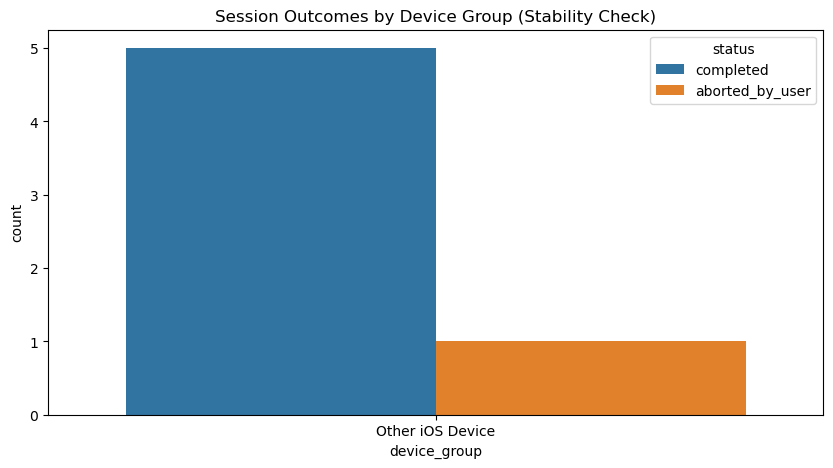

❄️ Sessions with UI Freezes: 0 / 6


In [16]:
# 1. Friction Analysis (Aborted Sessions per Device Group)
if not df.empty:
    friction_df = df[df['status'] != 'completed']
    
    plt.figure(figsize=(10, 5))
    sns.countplot(data=df, x='device_group', hue='status')
    plt.title('Session Outcomes by Device Group (Stability Check)')
    plt.show()
    
# 2. UI Freeze Detection (Simulated/Actual)
    # Assuming 'ui_freeze_count' > 0 implies main thread jank
    janks = df[df['ui_freeze_count'] > 0]
    print(f"❄️ Sessions with UI Freezes: {len(janks)} / {len(df)}")

## 4. 📈 Marketer Dashboard: Growth & Aha Moments
**Focus**: Onboarding Completion, TTM (Time to Magic).

🚀 Onboarding Completion Rate: 100.0%


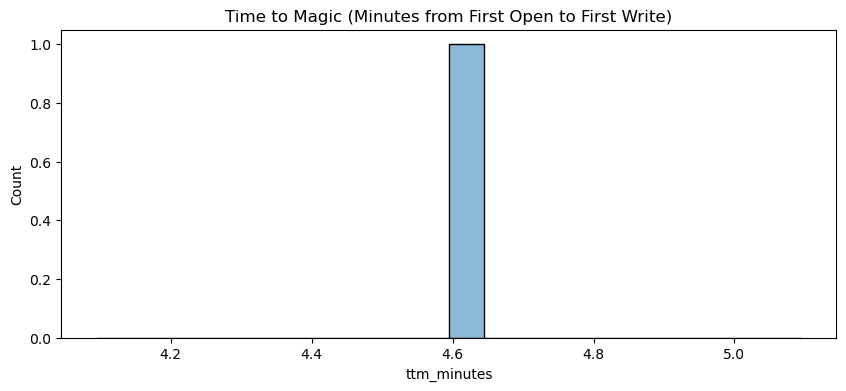

In [17]:
# 1. Onboarding Funnel
onboarding_logs = df[df['category'] == 'onboarding']
onboarding_rate = (len(onboarding_logs[onboarding_logs['status'] == 'completed']) / len(onboarding_logs)) * 100 if len(onboarding_logs) > 0 else 0
print(f"🚀 Onboarding Completion Rate: {onboarding_rate:.1f}%")

# 2. Time to Magic (TTM): Time from Install to First Completed Write
first_writes = df[(df['category'] == 'write_view') & (df['status'] == 'completed')].groupby('subject_id')['startTime'].min()
installs = df.groupby('subject_id')['startTime'].min()

ttm_df = pd.concat([installs, first_writes], axis=1, keys=['install_time', 'first_magic_time']).dropna()
ttm_df['ttm_minutes'] = (ttm_df['first_magic_time'] - ttm_df['install_time']).dt.total_seconds() / 60

if not ttm_df.empty:
    plt.figure(figsize=(10, 4))
    sns.histplot(ttm_df['ttm_minutes'], bins=20, kde=True)
    plt.title('Time to Magic (Minutes from First Open to First Write)')
    plt.show()

## 5. Feedback Loop Trigger: "The Struggler"
**Logic**: Identify users who recently struggled (Aborted session > Average Duration + 2 Sigma) to trigger In-App Survey.

In [18]:
def detect_strugglers(user_df):
    completed_writes = user_df[(user_df['category'] == 'write_view') & (user_df['status'] == 'completed')]
    if len(completed_writes) < 2: return [] # Not enough baseline
    
    # Personal Baseline
    avg_duration = completed_writes['total_duration'].mean()
    std_dev = completed_writes['total_duration'].std()
    if std_dev == 0 or np.isnan(std_dev): std_dev = 5 # Graceful fallback
    
    threshold = avg_duration + (2 * std_dev)
    
    # Find Anomalies
    struggles = user_df[
        (user_df['category'] == 'write_view') & 
        (user_df['status'] != 'completed') & 
        (user_df['total_duration'] > threshold)
    ]
    
    return struggles[['id', 'startTime', 'total_duration', 'status']]

# Run Detection for all users
struggling_sessions = df.groupby('subject_id').apply(detect_strugglers)

print("⚠️ Candidates for 'In-App Feedback Contextual Loop':")
print(struggling_sessions)

⚠️ Candidates for 'In-App Feedback Contextual Loop':
subject_id
2136E129-0F6F-435E-B5D6-7B7E56E4ADC3                                                   []
8EE2524A-5828-4430-8FBF-3A20CF6D5E56    Empty DataFrame
Columns: [id, startTime, total...
dtype: object


/var/folders/d1/886t6shj34s6pl2n57fjkmh80000gn/T/ipykernel_52413/790671680.py:22: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  struggling_sessions = df.groupby('subject_id').apply(detect_strugglers)
